# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [30]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Ismael Latorre Flores"            # Tu nombre completo
MATRICULA = "82568"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Ismael Latorre Flores
Matrícula: 82568
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [31]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Lucy Flores\Documents\BIG_DATA\Examen_1er_Parcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [33]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [34]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [35]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [36]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [37]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [38]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Que no hay valores nulos y el rango de años se maneja con enteros, la variable valor se maneja con float)*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [39]:
# Pregunta 1
columna_filtro = config['filtro_paises']
df_paises = df[df[columna_filtro].notnull()]

print(f"Número de países distintos: {df_paises['entity'].nunique()}")

Número de países distintos: 189


In [40]:
mayor_val = df_paises.sort_values('valor', ascending=False).head(10)
menor_val = df_paises.sort_values('valor', ascending=True).head(10)

print(mayor_val[['entity', 'year', 'valor']])
print(menor_val[['entity', 'year', 'valor']])

          entity  year      valor
69       Andorra  2006  85.056270
68       Andorra  2005  84.885210
70       Andorra  2007  84.741150
64       Andorra  2001  84.728065
67       Andorra  2004  84.604740
2117  Luxembourg  2017  84.553620
2119  Luxembourg  2019  84.505740
2118  Luxembourg  2018  84.496760
2116  Luxembourg  2016  84.465840
66       Andorra  2003  84.429360
       entity  year     valor
1931   Kuwait  2020  0.830784
1927   Kuwait  2016  0.859087
779   Comoros  2002  0.868431
778   Comoros  2001  0.871331
777   Comoros  2000  0.872753
784   Comoros  2007  0.886865
785   Comoros  2008  0.887536
1926   Kuwait  2015  0.893008
787   Comoros  2010  0.895492
788   Comoros  2011  0.896825


**Interpretación:**

*(Hay 189 paises distintos. Y andorra y luxemburgo son los paises con mayor consumo, ademas se repiten varias veces eso quiere decir que varias años el ranking ha estado dominado por estos paises, en cambio pasa lo mismo pero en menor consumo con comoros y kuwait)*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [41]:
# Pregunta 2
# Tu codigo aqui
pais1 = "Mexico"
pais2 = "Germany"

df_pais1 = df_paises[df_paises['entity'] == pais1]
df_pais2 = df_paises[df_paises['entity'] == pais2]

anio_inicio = max(df_pais1['year'].min(), df_pais2['year'].min())
anio_fin = min(df_pais1['year'].max(), df_pais2['year'].max())

df_comparacion = df_paises[
    (df_paises['entity'].isin([pais1, pais2])) &
    (df_paises['year'] >= anio_inicio) &
    (df_paises['year'] <= anio_fin)
]

print(f"Rango común: {anio_inicio} - {anio_fin}")
print(df_comparacion[['entity', 'year', 'valor']].sort_values(['entity', 'year']))


Rango común: 2000 - 2020
       entity  year      valor
1386  Germany  2000  79.264520
1387  Germany  2001  79.021740
1388  Germany  2002  78.862880
1389  Germany  2003  78.604610
1390  Germany  2004  78.549034
1391  Germany  2005  78.363940
1392  Germany  2006  78.511380
1393  Germany  2007  78.469210
1394  Germany  2008  78.513140
1395  Germany  2009  78.217540
1396  Germany  2010  78.340805
1397  Germany  2011  78.795494
1398  Germany  2012  78.722330
1399  Germany  2013  78.817345
1400  Germany  2014  78.857130
1401  Germany  2015  78.748020
1402  Germany  2016  78.920930
1403  Germany  2017  79.206490
1404  Germany  2018  79.313120
1405  Germany  2019  79.135445
1406  Germany  2020  78.830920
2289   Mexico  2000  43.696823
2290   Mexico  2001  43.486710
2291   Mexico  2002  43.310062
2292   Mexico  2003  43.456112
2293   Mexico  2004  43.573890
2294   Mexico  2005  43.666603
2295   Mexico  2006  44.073420
2296   Mexico  2007  42.525486
2297   Mexico  2008  42.630943
2298   Mexico 

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [42]:
# Pregunta 3
# Tu codigo aqui
paises_interes = ["Mexico", "Germany", "Brazil", "Nigeria", "Kuwait"]

anio_reciente = df_paises[df_paises['entity'].isin(paises_interes)]['year'].max()

df_q3 = df_paises[
    (df_paises['entity'].isin(paises_interes)) &
    (df_paises['year'] == anio_reciente)
].sort_values('valor', ascending=False)

print(f"Año más reciente: {anio_reciente}")
print(df_q3[['entity', 'valor']])

diferencia = df_q3['valor'].max() - df_q3['valor'].min()
print(f"Diferencia entre el más alto y el más bajo: {diferencia:.2f}")

Año más reciente: 2020
       entity      valor
1406  Germany  78.830920
503    Brazil  58.037422
2309   Mexico  42.036960
2604  Nigeria  25.195713
1931   Kuwait   0.830784
Diferencia entre el más alto y el más bajo: 78.00


**Interpretación:**

*(Paises de europa tienden a estar muy altos en valor, y paises de america tienden a tener un valor intermedio y parecido, y al parecer en kuwait esta prohibido el consumo de alcohol ya que cuentan con un valor muy bajo)*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [43]:
# Pregunta 4
# Tu codigo aqui
grupo_latam = ["Mexico", "Colombia", "Argentina"]
grupo_asia = ["China", "Japan", "Vietnam"]

anio_reciente_grupos = df_paises[
    df_paises['entity'].isin(grupo_latam + grupo_asia)
]['year'].max()

df_latam = df_paises[
    (df_paises['entity'].isin(grupo_latam)) &
    (df_paises['year'] == anio_reciente_grupos)
]
df_asia = df_paises[
    (df_paises['entity'].isin(grupo_asia)) &
    (df_paises['year'] == anio_reciente_grupos)
]

print("Latinoamérica:")
print(df_latam[['entity', 'valor']])
print(f"Promedio Latinoamérica: {df_latam['valor'].mean():.2f}")

print("\nAsia:")
print(df_asia[['entity', 'valor']])
print(f"Promedio Asia: {df_asia['valor'].mean():.2f}")


Latinoamérica:
         entity      valor
146   Argentina  71.019600
776    Colombia  40.875217
2309     Mexico  42.036960
Promedio Latinoamérica: 51.31

Asia:
       entity      valor
755     China  60.263940
1826    Japan  67.500060
3865  Vietnam  53.704433
Promedio Asia: 60.49


**Interpretación:**

*(Asia en promedio sale un poco mas alta, principalmente porque los tres paises mantienen valores similares, en cambio en latinoamerica tienden valores mas bajos por mexico y colombia sin embrargo argentina se va muy por encima del promedio de latinoamerica)*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [44]:
# Pregunta 5
# Tu codigo aqui
pais_tendencia = "Mexico" 

df_pais5 = df_paises[df_paises['entity'] == pais_tendencia].sort_values('year')

anio_max = df_pais5.loc[df_pais5['valor'].idxmax(), 'year']
valor_max = df_pais5['valor'].max()
anio_min = df_pais5.loc[df_pais5['valor'].idxmin(), 'year']
valor_min = df_pais5['valor'].min()

print(f"Máximo: {valor_max:.2f} en {anio_max}")
print(f"Mínimo: {valor_min:.2f} en {anio_min}")

print(df_pais5[['year', 'valor']])


Máximo: 44.07 en 2006
Mínimo: 41.94 en 2013
      year      valor
2289  2000  43.696823
2290  2001  43.486710
2291  2002  43.310062
2292  2003  43.456112
2293  2004  43.573890
2294  2005  43.666603
2295  2006  44.073420
2296  2007  42.525486
2297  2008  42.630943
2298  2009  42.772570
2299  2010  42.275200
2300  2011  42.341488
2301  2012  42.171944
2302  2013  41.940746
2303  2014  42.286865
2304  2015  42.922820
2305  2016  43.080498
2306  2017  43.575916
2307  2018  43.875687
2308  2019  43.971450
2309  2020  42.036960


**Interpretación:**

*(podemos ver que en México su tendencia es fluctuante ya a que atraves de los años se ha mantenido entre un promedio de 41.94  y 44.07  )*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [45]:
# Pregunta 6
# Tu codigo aqui
df_mexico = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year')

valor_inicial = df_mexico.iloc[0]['valor']
anio_inicial = df_mexico.iloc[0]['year']
valor_final = df_mexico.iloc[-1]['valor']
anio_final = df_mexico.iloc[-1]['year']

cambio_pct = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"{anio_inicial}: {valor_inicial:.2f}")
print(f"{anio_final}: {valor_final:.2f}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")

2000: 43.70
2020: 42.04
Cambio porcentual: -3.80%


**Interpretación:**

*(Con esto reafirmamos lo de la pregunta anterior que tiende a ser fluctuante, iclusive tuvo una caida relativamente pequeña, causada tal vez por el inicio de pandemia en 2020)*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [46]:
# Pregunta 7
# Tu codigo aqui
anio_mas_reciente = df_paises['year'].max()

valores_recientes = df_paises[df_paises['year'] == anio_mas_reciente]['valor']
valores_limpios = valores_recientes.dropna().to_numpy()

media = np.mean(valores_limpios)
mediana = np.median(valores_limpios)
desv_std = np.std(valores_limpios)

print(f"Año: {anio_mas_reciente}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desv_std:.2f}")

Año: 2020
Media: 42.25
Mediana: 42.04
Desviación estándar: 24.00


**Interpretación:**

*(se puede ver que la media y mediana lo que puede ser es que la distribucion esta casi igual entre continentes, pero en la desviacion estandar hay mucha variacion ya que como lo pudimos ver en las preguntas anteriores hay pasies con 0 de valor y otros con 80)*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

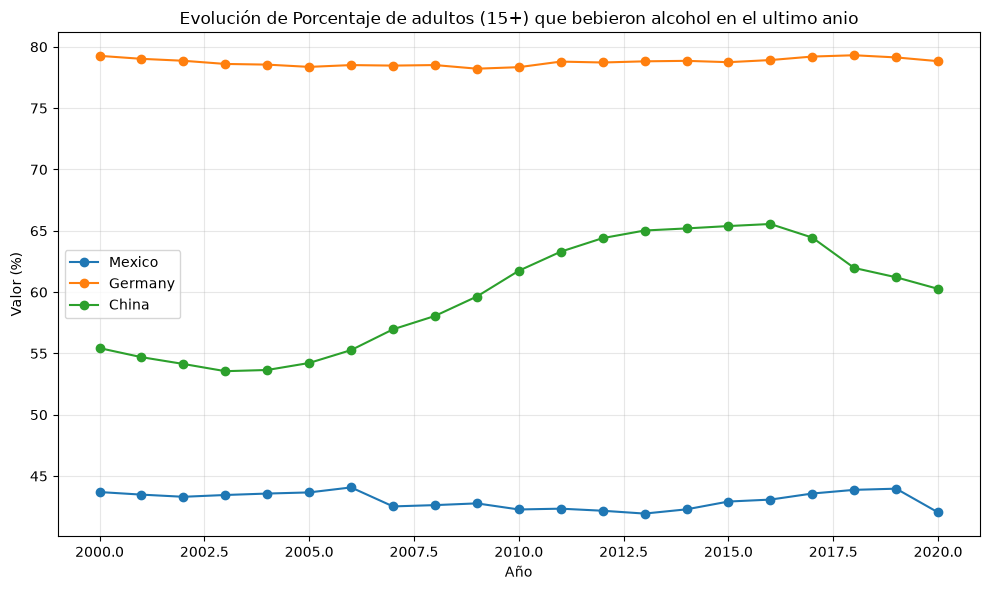

In [47]:
# Pregunta 8
# Tu codigo aqui
paises_grafica = ["Mexico", "Germany", "China"]

plt.figure(figsize=(10, 6))
for pais in paises_grafica:
    df_temp = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(df_temp['year'], df_temp['valor'], marker='o', label=pais)

plt.title(f"Evolución de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**

*(Podemos ver que México y Alemania mantenieron un valor constante de consumo de alcohol, en camnbio china si tuvo un ligero incremento en los ultimos años)*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

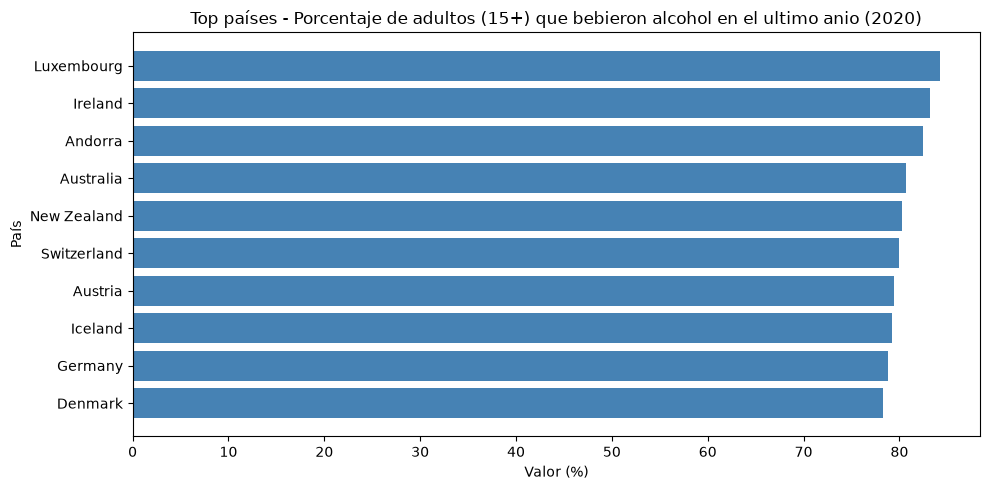

In [48]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2020

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*(En la grafica de mi año de nacimiento podemos ver que andorra fue el mas alto. Y en la segunda tabla se tuvo que utilizar el año 2020 ya que no hay registros hasta el 2023, Y en esta se observo que el mas alto fue luxemburgo lo que hace sentido a la primer pregunta donde se saca el top 10 de los paises mas altos a traves de un rango de años en el cual fueron estos dos los que mas aparecierón.)*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(En este analisis del dataset se observo y se investigo que el consumo de alcohol se ve muy limitado por factores religioso mas que por economicos. Ademas se observa un consumo mayor en paises de Europa. Y respecto a México se observa que se ha mantenido estable en esu consumo a traves de los años. Tambien se observo que existe una gran variacion de consumo entre distintos paises con una desviación estandar de 24. Y si tuviera mas tienpo investigaria más, por ejemplo por que paso con chino y porque incremento en el año 2017)*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
